In [2]:
import glob
import os
import pandas as pd

# Path to the directory where your downloaded CRMLSSold CSV files are stored
data_folder = "./data"  # Update with your local folder path
file_pattern = os.path.join(data_folder, "CRMLSSold*.csv")

# Get list of all matching monthly files (ensure at least 6 files are present)
file_list = sorted(glob.glob(file_pattern))

if len(file_list) < 6:
    print(f"Warning: Found only {len(file_list)} files. Ensure you have downloaded at least 6 months of data.")

# Load and combine all monthly datasets into a single DataFrame
df_list = [pd.read_csv(file, low_memory=False) for file in file_list]
df = pd.concat(df_list, ignore_index=True)

# Mandatory Task Filter: Residential Single Family Homes only
df_sfr = df[
    (df['PropertyType'] == 'Residential') & 
    (df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

# Convert CloseDate to datetime and verify the time range spans >= 6 months
df_sfr['CloseDate'] = pd.to_datetime(df_sfr['CloseDate'])
start_date = df_sfr['CloseDate'].min()
end_date = df_sfr['CloseDate'].max()

print(f"Successfully loaded {len(df_sfr):,} rows.")
print(f"Date range: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"Number of files/months: {len(file_list)}")

Successfully loaded 309,735 rows.
Date range: 2024-01-01 to 2026-04-30
Number of files/months: 28


=== Summary Statistics ===
                        count          mean           std       min  \
ClosePrice             2473.0  2.643718e+06  2.050413e+07  11000.00   
LivingArea             2473.0  2.350445e+03  1.177874e+03    400.00   
BedroomsTotal          2473.0  3.524060e+00  1.331535e+00      0.00   
BathroomsTotalInteger  2472.0  3.553398e+00  1.491776e+00      0.00   
LotSizeSquareFeet      2473.0  1.609308e+03  1.145019e+03      0.01   

                             50%          max  
ClosePrice             1250049.0  768500000.0  
LivingArea                2057.0      16683.0  
BedroomsTotal                3.0         45.0  
BathroomsTotalInteger        3.0         45.0  
LotSizeSquareFeet         1504.0      15560.0  


C:\Users\joeyw\AppData\Local\Temp\ipykernel_15452\1977248665.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean[col], y=df_clean['ClosePrice'], ax=axes[i, 1], palette='Set2')
C:\Users\joeyw\AppData\Local\Temp\ipykernel_15452\1977248665.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean[col], y=df_clean['ClosePrice'], ax=axes[i, 1], palette='Set2')


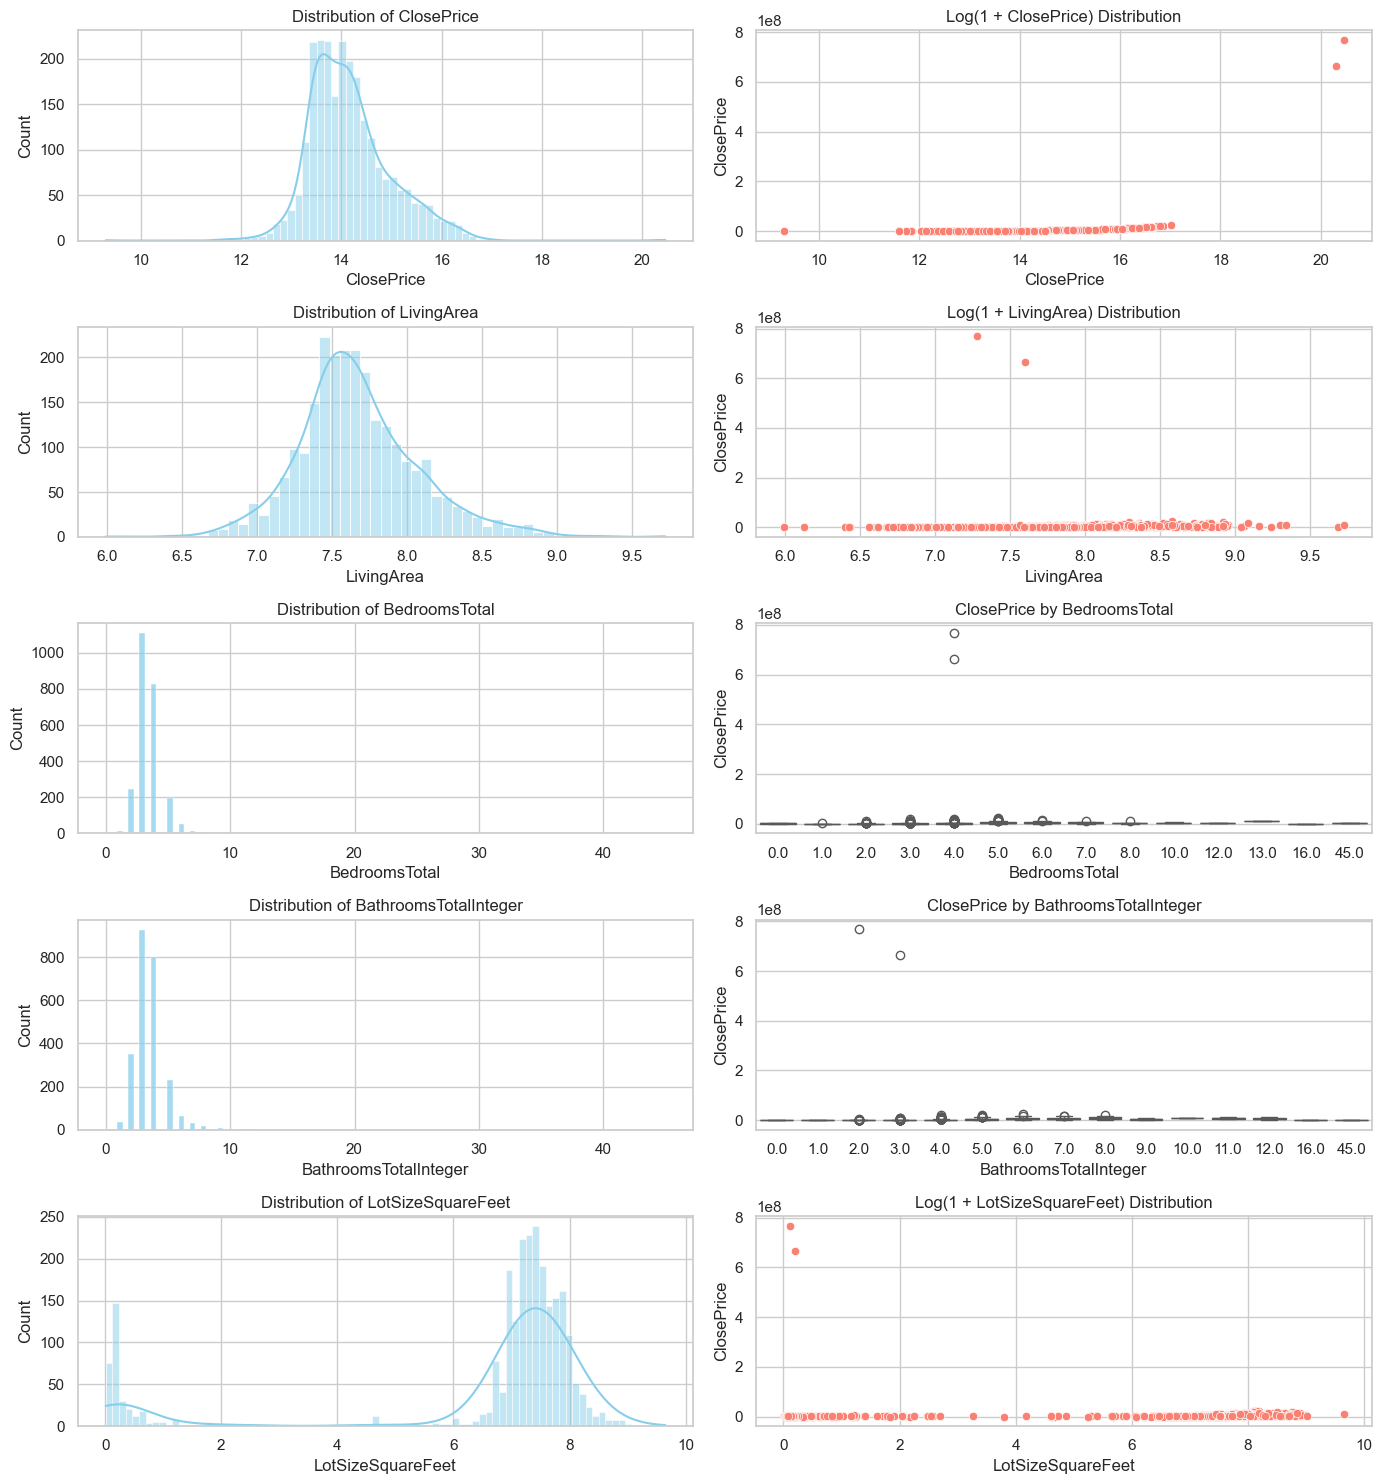

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# 2. Remove non-positive targets and structural impossibilities
df_clean = df_sfr[
    (df_sfr['ClosePrice'] > 0) & 
    (df_sfr['LivingArea'] > 0) & 
    (df_sfr['LotSizeSquareFeet'] > 0) &
    (df_sfr['LotSizeSquareFeet'] < df_sfr['LivingArea'])
].copy()

# Target and physical features to analyze
features = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet']

# 3. Print Summary Statistics
print("=== Summary Statistics ===")
print(df_clean[features].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])
# df_clean[features].describe() calculates summary statistics (count, mean, std, min, percentiles, max) where features are columns and statistics are rows.
# Applying .T (or .transpose()) flips the matrix so that:
# Rows become feature names (e.g., LivingArea, BedroomsTotal, ClosePrice).
# Columns become statistical summary names (count, mean, std, etc.)

# 4. Plot Distributions
fig, axes = plt.subplots(len(features), 2, figsize=(14, 3 * len(features)))
# len(features) rows: Creates one row of subplots for each feature in your list.
# 2 columns: Allocates 2 subplot columns per feature (typically left = histogram/KDE, right = boxplot or scatter plot).
# figsize=(14, 3 * len(features)): Dynamically sets the total image dimensions to 14 inches wide and 3 inches high per feature row, preventing subplots from squishing vertically when you add more features.
# axes: Returns a 2D NumPy array of shape (len(features), 2) containing plot handles.

for i, col in enumerate(features):

    if col in ['BedroomsTotal', 'BathroomsTotalInteger']:
        # Raw Distribution
        sns.histplot(df_clean[col].dropna(), kde=False, ax=axes[i, 0], color='skyblue')
        axes[i, 0].set_title(f'Distribution of {col}')
    else:
        sns.histplot(np.log1p(df_clean[col].dropna()), kde=True, ax=axes[i, 0], color='skyblue')
        axes[i, 0].set_title(f'Distribution of {col}')

    
    # Log-transformed Distribution (or Boxplot for discrete counts)
    if col in ['BedroomsTotal', 'BathroomsTotalInteger']:
        sns.boxplot(x=df_clean[col], y=df_clean['ClosePrice'], ax=axes[i, 1], palette='Set2')
        axes[i, 1].set_title(f'ClosePrice by {col}')
    else:
        sns.scatterplot(x = np.log1p(df_clean[col].dropna()), y=df_clean['ClosePrice'], ax=axes[i, 1], color='salmon')
        # np.log1p calculates y = \ln(1 + x). Mainly does log transformation and prevents division by zero
        axes[i, 1].set_title(f'Log(1 + {col}) Distribution')

plt.tight_layout()
plt.show()